Loading data...
Loaded 29 scraped records.
Aggregating daily prices...
Training ARIMA model and forecasting...

Forecast for next 5 days:
            forecast_price_per_kg
2026-05-02              44.960804
2026-05-03              45.265594
2026-05-04              43.595528
2026-05-05              41.123923
2026-05-06              39.169415

Model Summary:
                               SARIMAX Results                                
Dep. Variable:           price_per_kg   No. Observations:                    8
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 -18.136
Date:                Fri, 24 Apr 2026   AIC                             46.272
Time:                        09:35:05   BIC                             46.001
Sample:                    04-24-2026   HQIC                            42.929
                         - 05-01-2026                                         
Covariance Type:                  opg                                         
          

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


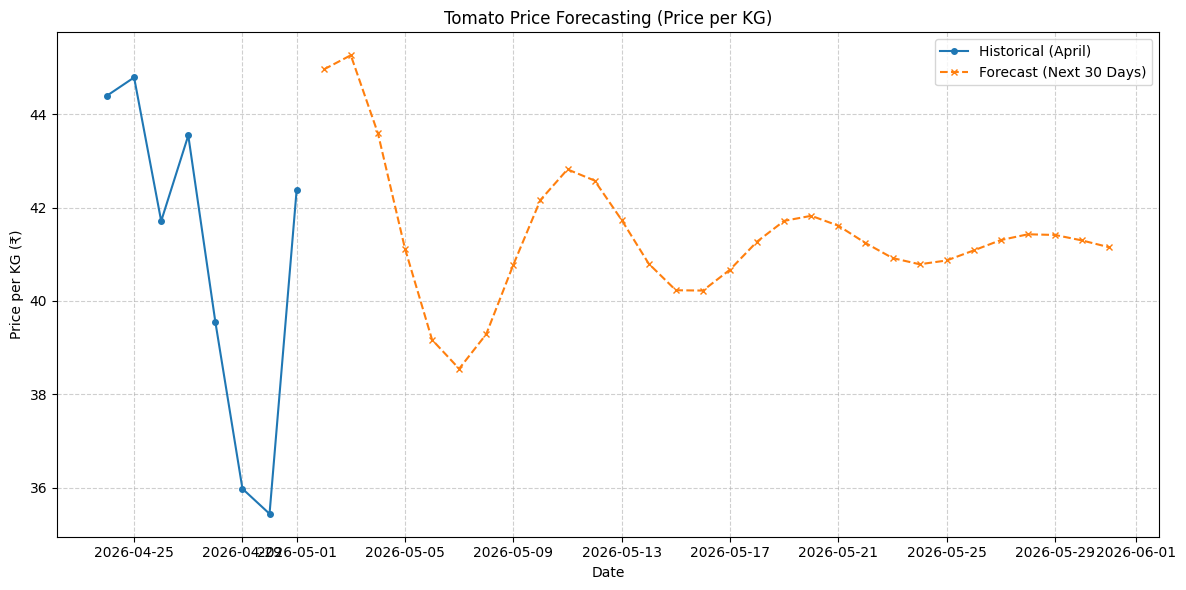

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta

# -------------------------------
# 1. Generate Mock Scraped Data
# -------------------------------
def generate__scraped_data():
    np.random.seed(42)
    dates = pd.date_range(start="2026-04-24", end="2026-05-01")
    platforms = ['Zepto', 'BigBasket', 'Instamart']

    data = []
    for date in dates:
        for _ in range(np.random.randint(2, 6)):
            platform = np.random.choice(platforms)
            base_price_kg = 40 + np.sin(date.day / 3) * 5 + np.random.normal(0, 2)
            weight_kg = np.random.choice([0.25, 0.5, 1.0])

            price = round(base_price_kg * weight_kg, 2)
            mrp = round(price * 1.2, 2)
            discount = round(mrp - price, 2)

            data.append({
                'date': date,
                'platform': platform,
                'brand': 'Fresho' if platform == 'BigBasket' else 'Local',
                'product_name': f'Tomato - {int(weight_kg*1000)}g',
                'weight_kg': weight_kg,
                'price': price,
                'mrp': mrp,
                'discount': discount,
                'price_per_kg': round(price / weight_kg, 2)
            })

    return pd.DataFrame(data)

# -------------------------------
# 2. Prepare Time Series
# -------------------------------
def prepare_time_series(df):
    df['date'] = pd.to_datetime(df['date'])

    daily_avg = df.groupby('date')['price_per_kg'].mean().reset_index()
    daily_avg.set_index('date', inplace=True)

    # Ensure continuous daily data
    daily_avg = daily_avg.resample('D').mean().ffill()
    daily_avg = daily_avg.asfreq('D')

    return daily_avg

# -------------------------------
# 3. Forecast Prices (ARIMA)
# -------------------------------
def forecast_prices(ts_data, forecast_days=30):
    model = ARIMA(ts_data['price_per_kg'], order=(2, 1, 2))
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=forecast_days)

    last_date = ts_data.index[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=forecast_days)

    forecast_df = pd.DataFrame({
        'forecast_price_per_kg': forecast.values
    }, index=future_dates)

    return forecast_df, fitted_model

# -------------------------------
# 4. Plot Forecast
# -------------------------------
def plot_forecast(historical_data, forecast_data):
    plt.figure(figsize=(12, 6))

    # Historical data
    plt.plot(
        historical_data.index,
        historical_data['price_per_kg'],
        label='Historical (April)',
        marker='o',
        markersize=4
    )

    # Forecast data
    plt.plot(
        forecast_data.index,
        forecast_data['forecast_price_per_kg'],
        label='Forecast (Next 30 Days)',
        linestyle='--',
        marker='x',
        markersize=4
    )

    plt.title('Tomato Price Forecasting (Price per KG)')
    plt.xlabel('Date')
    plt.ylabel('Price per KG (₹)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------
# 5. Main Execution
# -------------------------------
if __name__ == "__main__":
    print("Loading data...")
    raw_df = generate__scraped_data()
    print(f"Loaded {len(raw_df)} scraped records.")

    print("Aggregating daily prices...")
    ts_data = prepare_time_series(raw_df)

    print("Training ARIMA model and forecasting...")
    forecast_df, model = forecast_prices(ts_data, forecast_days=30)

    print("\nForecast for next 5 days:")
    print(forecast_df.head())

    print("\nModel Summary:")
    print(model.summary())

    plot_forecast(ts_data, forecast_df)